# Omega_GW(f) from the tabulated kernels
Folds a flat and a lognormal P_zeta through the exported kernels_data/ tables (kernel_table_io.KernelTable), no mode-function solve needed.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../core'))
import numpy as np
import matplotlib.pyplot as plt
import plotstyle; plotstyle.use_latex()
import spectra as sp
import background_qcd as qcd
from kernel_table_io import KernelTable

table = KernelTable()
print(f'{len(table.k_nodes)} k-nodes, t-grid {len(table.t)}, s-grid {len(table.s)}')

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta)...
  norm = 0.9836281477
60 k-nodes, t-grid 1111, s-grid 18


In [2]:
A_ZETA = 0.01
K_STAR = table.k_nodes[len(table.k_nodes) // 2]
SIGMA = 0.4
ETA_F = 1e4   # deep in the frozen-g* regime, see notebook 01

pz_flat = sp.make_pzeta(('flat',))
pz_ln = sp.make_pzeta(('lognormal', K_STAR, SIGMA))

omega_flat = np.array([sp.omega_gw(k, A_ZETA**2 * table.Ph(k, pz_flat), qcd, ETA_F) for k in table.k_nodes])
omega_ln = np.array([sp.omega_gw(k, A_ZETA**2 * table.Ph(k, pz_ln), qcd, ETA_F) for k in table.k_nodes])
f_Hz = sp.k_to_f_Hz(table.k_nodes)
print('done')

done


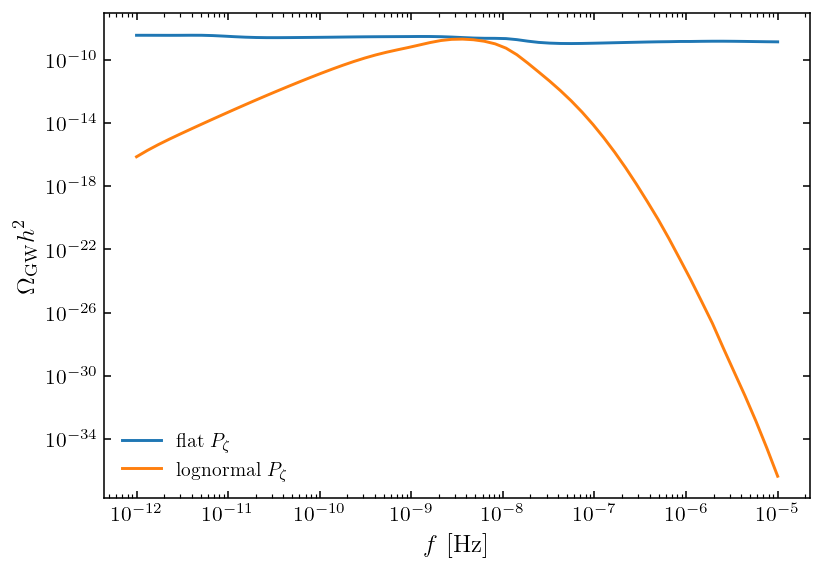

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(f_Hz, omega_flat * sp.OMEGA_R0_H2, label='flat $P_\\zeta$')
ax.loglog(f_Hz, omega_ln * sp.OMEGA_R0_H2, label='lognormal $P_\\zeta$')
ax.set_xlabel('$f$ [Hz]'); ax.set_ylabel(r'$\Omega_{\rm GW}h^2$'); ax.legend()
plt.show()